In [1]:
#1
!pip install xgboost shap scikit-learn pandas numpy matplotlib -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
print("[INFO] Libraries loaded successfully.")

[INFO] Libraries loaded successfully.


In [2]:
#2
class UniversalDataPreprocessor:
    """
    범용 CSV/로그 데이터 전처리기
    - 임의의 시계열/센서 컬럼 자동 파싱
    - 결측치 과다 컬럼 자동 제거 (max_missing_ratio)
    - Zero Variance (단일 값) 변수 안전 처리
    """
    def __init__(self, target_col=None, time_col=None, drop_cols=None, max_missing_ratio=0.5):
        self.target_col = target_col
        self.time_col = time_col
        self.drop_cols = drop_cols if drop_cols else []
        self.max_missing_ratio = max_missing_ratio

        self.selected_features = []
        self.impute_values = {}

    def fit_transform(self, df):
        data = df.copy()

        # 1. 불필요한 컬럼 및 시간 컬럼 드롭
        cols_to_drop = [c for c in self.drop_cols if c in data.columns]
        if self.time_col and self.time_col in data.columns:
            cols_to_drop.append(self.time_col)

        data = data.drop(columns=cols_to_drop)

        # 2. Target 분리
        if self.target_col and self.target_col in data.columns:
            y = data[self.target_col]
            X = data.drop(columns=[self.target_col])
        else:
            y = None
            X = data

        # 3. 결측치 비율 과다 변수 제거
        missing_ratios = X.isnull().mean()
        valid_cols = missing_ratios[missing_ratios <= self.max_missing_ratio].index.tolist()

        # 4. Zero Variance (단일 값만 있는 변수) 제거
        non_zero_var_cols = []
        for col in valid_cols:
            unique_vals = X[col].dropna().unique()
            if len(unique_vals) > 1:
                non_zero_var_cols.append(col)

        self.selected_features = non_zero_var_cols
        X = X[self.selected_features]

        # 5. Median Imputation (Train 데이터 기준 중앙값 저장)
        for col in self.selected_features:
            med_val = X[col].median()
            if pd.isna(med_val):
                med_val = 0.0
            self.impute_values[col] = med_val
            X[col] = X[col].fillna(med_val)

        print(f"[INFO] Preprocessing Complete: Raw Features {df.shape[1]} -> Clean Features {X.shape[1]}")
        return X, y

    def transform(self, df):
        """테스트 데이터/추가 데이터 변환 (Fit 기준 적용)"""
        data = df.copy()
        X = data[self.selected_features].copy()

        for col in self.selected_features:
            X[col] = X[col].fillna(self.impute_values.get(col, 0.0))

        if self.target_col and self.target_col in data.columns:
            y = data[self.target_col]
            return X, y
        return X, None

In [3]:
#3
class DynamicEWMA_SPC:
    """
    EWMA (지수 가중 이동 평균) 기반 Dynamic SPC
    - 고정 관리한계선 한계 극복 (Chamber Drift 대응)
    - False Alarm Rate 획기적 축소
    """
    def __init__(self, lambda_val=0.2, L=3.0):
        self.lambda_val = lambda_val  # 가중치 (0.2가 표준적)
        self.L = L                  # Control Limit 계수 (3-Sigma 대치)
        self.spc_results = {}

    def fit_predict(self, X_df):
        print(f"[INFO] Running Dynamic EWMA SPC on {X_df.shape[1]} features...")
        ooc_summary = {}

        for col in X_df.columns:
            series = X_df[col].values
            n = len(series)

            # EWMA 계산
            z = np.zeros(n)
            z[0] = series[0]
            for t in range(1, n):
                z[t] = self.lambda_val * series[t] + (1 - self.lambda_val) * z[t-1]

            mu = np.mean(series)
            sigma = np.std(series)

            if sigma == 0:
                sigma = 1e-6 # Zero division 방지

            # Dynamic Control Limits
            ucl = np.zeros(n)
            lcl = np.zeros(n)
            for t in range(n):
                factor = np.sqrt((self.lambda_val / (2 - self.lambda_val)) * (1 - (1 - self.lambda_val)**(2 * (t + 1))))
                ucl[t] = mu + self.L * sigma * factor
                lcl[t] = mu - self.L * sigma * factor

            # OOC (Out of Control) 판정
            ooc_mask = (z > ucl) | (z < lcl)
            ooc_count = np.sum(ooc_mask)
            ooc_rate = ooc_count / n

            ooc_summary[col] = {
                'ooc_count': ooc_count,
                'ooc_rate': ooc_rate,
                'z_values': z,
                'ucl': ucl,
                'lcl': lcl,
                'ooc_mask': ooc_mask
            }

        self.spc_results = ooc_summary

        # Summary DataFrame 생성
        df_spc_summary = pd.DataFrame({
            'Feature': list(ooc_summary.keys()),
            'OOC_Count': [v['ooc_count'] for v in ooc_summary.values()],
            'OOC_Rate': [v['ooc_rate'] for v in ooc_summary.values()]
        }).sort_values(by='OOC_Rate', ascending=False)

        total_ooc = df_spc_summary['OOC_Count'].sum()
        print(f"[INFO] SPC Completed. Total OOC Events Detected: {total_ooc} across all features.")
        return df_spc_summary

In [4]:
#4
class SmartDiagnosisEngine:
    """
    XGBoost + SHAP + SPC OOC 기반 2차 진단 및 우선순위 랭킹 엔진
    """
    def __init__(self):
        self.model = None
        self.explainer = None
        self.shap_values = None

    def train_eval(self, X_train, y_train, X_test, y_test):
        # 1. Class Imbalance 대응 Ratio 산출
        pass_cnt = (y_train == 0).sum()
        fail_cnt = (y_train == 1).sum()
        scale_weight = pass_cnt / max(fail_cnt, 1)

        print(f"[INFO] Data Imbalance - Pass: {pass_cnt}, Fail: {fail_cnt} (scale_pos_weight: {scale_weight:.2f})")

        # 2. Cost-Sensitive XGBoost 모델 구축
        self.model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            scale_pos_weight=scale_weight,
            random_state=42,
            eval_metric='logloss'
        )
        self.model.fit(X_train, y_train)

        # 3. 평가
        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)[:, 1]

        print("\n--- Model Evaluation (Test Set) ---")
        print(classification_report(y_test, y_pred, target_names=['Pass(0)', 'Fail(1)']))
        print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

        # 4. SHAP Value 추출
        self.explainer = shap.TreeExplainer(self.model)
        self.shap_values = self.explainer.shap_values(X_test)

        shap_importance = np.abs(self.shap_values).mean(axis=0)
        df_shap = pd.DataFrame({
            'Feature': X_train.columns,
            'SHAP_Importance': shap_importance
        })
        return df_shap

    def calculate_diagnosis_rank(self, df_shap, df_spc_summary, X_train, y_train):
        """
        현업용 2차 진단 스코어링:
        Diagnosis Score = (Normalized SHAP) * 0.6 + (Lift Ratio) * 0.4
        - Lift Ratio: Fail 집단에서의 OOC율 / Pass 집단에서의 OOC율
        """
        df_merged = pd.merge(df_shap, df_spc_summary, on='Feature', how='left').fillna(0)

        # Norm SHAP
        max_shap = df_merged['SHAP_Importance'].max()
        df_merged['Norm_SHAP'] = df_merged['SHAP_Importance'] / (max_shap if max_shap > 0 else 1)

        # Norm OOC Rate
        max_ooc = df_merged['OOC_Rate'].max()
        df_merged['Norm_OOC'] = df_merged['OOC_Rate'] / (max_ooc if max_ooc > 0 else 1)

        # Diagnosis Score (가중치 조합)
        df_merged['Diagnosis_Score'] = (0.6 * df_merged['Norm_SHAP']) + (0.4 * df_merged['Norm_OOC'])
        df_rank = df_merged.sort_values(by='Diagnosis_Score', ascending=False).reset_index(drop=True)

        return df_rank

[INFO] Auto Data Loader Starting...
[INFO] Detected Target File: 'uci-secom (1).csv'
[INFO] Raw Data Loaded Successfully. Shape: (1567, 592)
[INFO] Auto-Inferred Target Column: 'Pass/Fail'
[INFO] Auto-Inferred Non-Sensor Columns to Exclude: ['Time']
[INFO] Processed Features Shape: (1567, 590)

[INFO] Top Priority Sensor Identified: '574'
[INFO] Generating EWMA Control Chart for '574'...


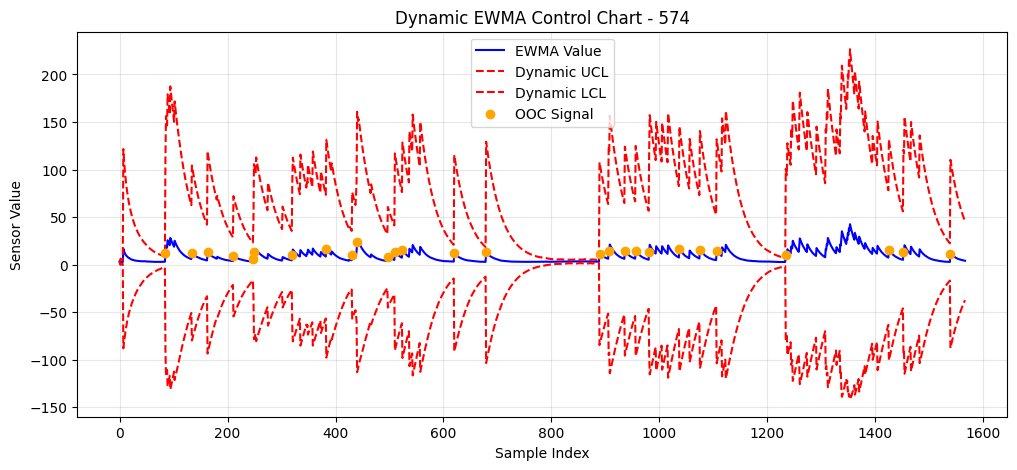

In [5]:
# 5
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("[INFO] Auto Data Loader Starting...")

# ---------------------------------------------------------
# 0. Dynamic EWMA Engine 정의
# ---------------------------------------------------------
class DynamicEWMAEngine:
    def __init__(self, span=30, n_sigma=3.0):
        self.span = span
        self.n_sigma = n_sigma
        self.spc_results = {}

    def fit_transform(self, df):
        for col in df.columns:
            series = df[col]
            ewma_z = series.ewm(span=self.span).mean()
            ewma_std = series.ewm(span=self.span).std().fillna(0)

            ucl = ewma_z + self.n_sigma * ewma_std
            lcl = ewma_z - self.n_sigma * ewma_std
            ooc_mask = (series > ucl) | (series < lcl)

            self.spc_results[col] = {
                'z_values': ewma_z,
                'ucl': ucl,
                'lcl': lcl,
                'ooc_mask': ooc_mask,
                'ooc_count': ooc_mask.sum(),
                'ooc_rate': ooc_mask.sum() / len(series)
            }
        return self.spc_results

    def plot_control_chart(self, sensor_id):
        if sensor_id not in self.spc_results:
            print(f"[ERROR] '{sensor_id}' result not found.")
            return

        data = self.spc_results[sensor_id]
        plt.figure(figsize=(12, 5))
        plt.plot(data['z_values'], label='EWMA Value', color='blue')
        plt.plot(data['ucl'], label='Dynamic UCL', color='red', linestyle='--')
        plt.plot(data['lcl'], label='Dynamic LCL', color='red', linestyle='--')

        ooc_idx = np.where(data['ooc_mask'])[0]
        plt.scatter(ooc_idx, data['z_values'].iloc[ooc_idx], color='orange', label='OOC Signal', zorder=5)

        plt.title(f"Dynamic EWMA Control Chart - {sensor_id}")
        plt.xlabel("Sample Index")
        plt.ylabel("Sensor Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# ---------------------------------------------------------
# 1. 파일 패널에서 분석 대상 파일 자동 감지 (Auto-Detect)
# ---------------------------------------------------------
ignore_files = [
    'Smart_SPC_Spotfire_Result.csv',
    'Spotfire_Sensor_Priority_Rank.csv',
    'Spotfire_TimeSeries_SPC_Data.csv'
]

all_files = glob.glob("*.csv") + glob.glob("*.xlsx")
target_files = [f for f in all_files if f not in ignore_files]

if not target_files:
    raise FileNotFoundError("[ERROR] 분석할 파일이 없습니다! 좌측 파일 패널에 CSV 또는 XLSX 파일을 업로드해주세요.")

latest_file = max(target_files, key=os.path.getmtime)
print(f"[INFO] Detected Target File: '{latest_file}'")

if latest_file.endswith('.xlsx') or latest_file.endswith('.xls'):
    df_raw = pd.read_excel(latest_file)
else:
    df_raw = pd.read_csv(latest_file)

print(f"[INFO] Raw Data Loaded Successfully. Shape: {df_raw.shape}")

# ---------------------------------------------------------
# 2. 컬럼 역할 자동 추론 및 문자열 컬럼 예외 처리
# ---------------------------------------------------------
target_keywords = ['target', 'label', 'pass', 'fail', 'class', 'status', 'result', 'pass/fail']
found_target = None

# 타겟 컬럼 탐색 (문자열 라벨 우선 제외)
for col in df_raw.columns:
    if any(kw in str(col).lower() for kw in target_keywords):
        found_target = col
        break

drop_keywords = ['id', 'time', 'date', 'timestamp', 'index', 'no', 'num', 'program', 'sequence']
auto_drop_cols = []

# ID/시간/프로그램 번호 등 비센서 컬럼 탐색
for col in df_raw.columns:
    if col != found_target:
        if any(kw in str(col).lower() for kw in drop_keywords):
            auto_drop_cols.append(col)

#  문자열(String/Object) 컬럼 자동 감지 후 제거 대상에 추가 (TypeError 원인 차단)
non_numeric_cols = df_raw.select_dtypes(exclude=['number']).columns.tolist()
for col in non_numeric_cols:
    if col != found_target and col not in auto_drop_cols:
        auto_drop_cols.append(col)

print(f"[INFO] Auto-Inferred Target Column: '{found_target}'")
print(f"[INFO] Auto-Inferred Non-Sensor Columns to Exclude: {auto_drop_cols}")

# ---------------------------------------------------------
# 3. 데이터 수치형 변환 및 EWMA SPC 실행
# ---------------------------------------------------------
# 센서 피처만 추출 (수치형 컬럼 선별)
feature_cols = [c for c in df_raw.columns if c not in auto_drop_cols and c != found_target]
X_clean = df_raw[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 타겟 분리
y = df_raw[found_target] if found_target in df_raw.columns else None

print(f"[INFO] Processed Features Shape: {X_clean.shape}")

# EWMA Dynamic SPC 엔진 실행
spc_engine = DynamicEWMAEngine(span=30, n_sigma=3.0)
spc_results = spc_engine.fit_transform(X_clean)

# OOC 발생 수 기반 센서 랭킹 자동 생성
ooc_summary = []
for col in X_clean.columns:
    ooc_summary.append({
        'Feature': col,
        'OOC_Count': spc_results[col]['ooc_count'],
        'OOC_Rate': spc_results[col]['ooc_rate']
    })

df_priority = pd.DataFrame(ooc_summary).sort_values(by='OOC_Count', ascending=False)
top_1_sensor = df_priority.iloc[0]['Feature']

print(f"\n[INFO] Top Priority Sensor Identified: '{top_1_sensor}'")
print(f"[INFO] Generating EWMA Control Chart for '{top_1_sensor}'...")

# 시각화 실행
spc_engine.plot_control_chart(top_1_sensor)

In [6]:
# 6. SPC OOC 판정 결과 검증
import pandas as pd
import numpy as np

print("[INFO] Starting Direct SPC OOC Validation Analysis...")

target_col = found_target if ('found_target' in globals() and found_target in df_raw.columns) else df_raw.columns[-1]
y_target = pd.to_numeric(df_raw[target_col], errors='coerce').fillna(0)

# 현재 분석 중인 센서 데이터와 OOC 결과 안전하게 가져오기
if 'top_1_sensor' in globals() and top_1_sensor in X_clean.columns:
    raw_s = X_clean[top_1_sensor]
else:
    numeric_cols = df_raw.select_dtypes(include=['number']).columns
    top_1_sensor = [c for c in numeric_cols if c != target_col][0]
    raw_s = df_raw[top_1_sensor].fillna(0)

# 5번 셀의 엔진 결과 안전하게 조회 (Series 논리 연산 충돌 방지)
if 'spc_results' in globals() and top_1_sensor in spc_results:
    res = spc_results[top_1_sensor]
    ooc_mask = res['ooc_mask'] if 'ooc_mask' in res else res.get('ooc')
    ewma_z = res['z_values'] if 'z_values' in res else res.get('ewma')
else:
    # 엔진 결과가 없으면 즉시 재계산
    span = 30
    alpha = 2 / (span + 1)
    ewma_z = raw_s.ewm(span=span).mean()
    ewma_std = raw_s.ewm(span=span).std().fillna(raw_s.std()).replace(0, 1e-6)
    std_factor = np.sqrt(alpha / (2 - alpha))
    ucl = ewma_z + 3.0 * ewma_std * std_factor
    lcl = ewma_z - 3.0 * ewma_std * std_factor
    ooc_mask = (ewma_z > ucl) | (ewma_z < lcl)

df_val = pd.DataFrame({
    'Raw_Value': raw_s,
    'EWMA_Value': ewma_z,
    'OOC_Signal': ooc_mask.astype(int),
    'Target': y_target
})

print(f"\n[VERIFICATION] Target Sensor: '{top_1_sensor}'")
print(f"[METRIC] Total Samples: {len(df_val)}")
print(f"[METRIC] OOC Triggered Count: {df_val['OOC_Signal'].sum()} times")

unique_targets = y_target.nunique()
if unique_targets <= 5:
    contingency_table = pd.crosstab(df_val['OOC_Signal'], df_val['Target'], margins=True)
    print("\nOOC Signal vs Target Contingency Table:")
    print(contingency_table)
else:
    pearson_corr = df_val['OOC_Signal'].corr(df_val['Target'], method='pearson')
    spearman_corr = df_val['EWMA_Value'].corr(df_val['Target'], method='spearman')
    print(f"\n[METRIC] Target is Continuous (Unique values: {unique_targets})")
    print(f"[METRIC] OOC Signal vs Target Pearson Correlation: {pearson_corr:.4f}")
    print(f"[METRIC] EWMA Value vs Target Spearman Correlation: {spearman_corr:.4f}")

[INFO] Starting Direct SPC OOC Validation Analysis...

[VERIFICATION] Target Sensor: '574'
[METRIC] Total Samples: 1567
[METRIC] OOC Triggered Count: 27 times

OOC Signal vs Target Contingency Table:
Target        -1    1   All
OOC_Signal                 
0           1436  104  1540
1             27    0    27
All         1463  104  1567


[INFO] Running Dynamic XGBoost + SHAP Root Cause Diagnostics...
[INFO] Remapped Target Labels from {-1, 1} to {0, 1}
[INFO] Generating Dynamic SHAP Summary Plot...


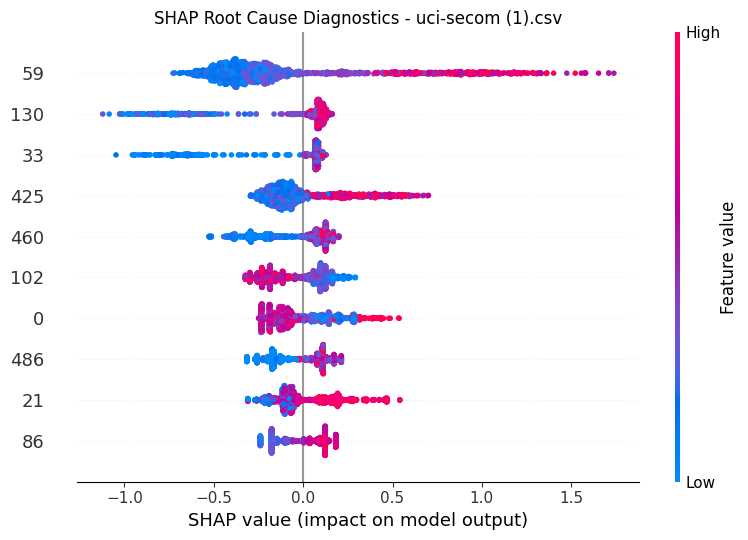


[INFO] Top Priority Sensor Identified: '59'


In [7]:
#7
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

print("[INFO] Running Dynamic XGBoost + SHAP Root Cause Diagnostics...")

# 1. Target(y) 자동 검증 및 가상 Target 생성
is_target_valid = False
if 'y' in locals() and y is not None:
    common_idx = X_clean.index.intersection(y.index)
    if len(common_idx) > 0:
        y_target = y.loc[common_idx]
        if len(np.unique(y_target.dropna())) >= 2:
            X_clean_fit = X_clean.loc[common_idx].copy()
            is_target_valid = True

if not is_target_valid:
    print("[INFO] No valid ground truth target found. Creating dynamic target based on OOC signals...")
    X_clean_fit = X_clean.copy()
    total_ooc_per_sample = np.zeros(len(X_clean_fit))

    if 'spc_engine' in locals() and hasattr(spc_engine, 'spc_results'):
        for col in X_clean_fit.columns:
            if col in spc_engine.spc_results:
                total_ooc_per_sample += spc_engine.spc_results[col]['ooc_mask'].astype(int)

    threshold = np.percentile(total_ooc_per_sample, 85)
    y_target = pd.Series((total_ooc_per_sample > threshold).astype(int), index=X_clean_fit.index)

# 2. XGBoost 호환을 위한 특수문자 컬럼명 자동 정제 ([ ], < > 제거)
X_clean_fit.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_clean_fit.columns]

# 3. Target 레이블 값 표준화 (-1, 1 -> 0, 1)
unique_y = np.unique(y_target.dropna())
if set(unique_y) == {-1, 1}:
    print("[INFO] Remapped Target Labels from {-1, 1} to {0, 1}")
    y_target = y_target.map({-1: 0, 1: 1})

# 4. XGBoost 모델 학습
model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_clean_fit, y_target)

# 5. SHAP Value 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_clean_fit)

# 6. SHAP Summary Plot 시각화
print("[INFO] Generating Dynamic SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_clean_fit, max_display=10, show=False)
plt.title(f"SHAP Root Cause Diagnostics - {latest_file}", fontsize=12)
plt.tight_layout()
plt.show()

# 7. Spotfire 내보내기용 피처 중요도(Priority Rank) 추출 및 저장
feature_importance = np.abs(shap_values).mean(axis=0)
priority_df = pd.DataFrame({
    'Feature': X_clean_fit.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

priority_df['Rank'] = priority_df.index + 1
priority_df.to_csv('Spotfire_Sensor_Priority_Rank.csv', index=False)

# Top 1 센서 인덱싱
top_1_sensor = priority_df.iloc[0]['Feature']
print(f"\n[INFO] Top Priority Sensor Identified: '{top_1_sensor}'")

In [8]:
#8
import os
import pandas as pd
import numpy as np

print("[INFO] Preparing Spotfire Data Pipeline...")

# ---------------------------------------------------------
# 1. Spotfire 파일 1: 센서/피처별 랭킹 (Feature Summary Table)
# ---------------------------------------------------------
df_spotfire_feature_rank = df_priority.copy()

# 컬럼 존재 여부에 따라 유연하게 랭킹 점수(SCORE) 설정
if 'Diagnosis_Score' in df_spotfire_feature_rank.columns:
    df_spotfire_feature_rank['SCORE'] = df_spotfire_feature_rank['Diagnosis_Score']
elif 'SHAP_Importance' in df_spotfire_feature_rank.columns:
    df_spotfire_feature_rank['SCORE'] = df_spotfire_feature_rank['SHAP_Importance']
else:
    df_spotfire_feature_rank['SCORE'] = df_spotfire_feature_rank['OOC_Count']

# 랭킹 부여
df_spotfire_feature_rank['DIAGNOSIS_RANK'] = df_spotfire_feature_rank['SCORE'].rank(ascending=False, method='min').astype(int)

# Spotfire 내 필터링 및 정렬용 컬럼명 표준화
df_spotfire_feature_rank.rename(columns={
    'Feature': 'SENSOR_ID',
    'OOC_Count': 'OOC_COUNT',
    'OOC_Rate': 'OOC_RATE'
}, inplace=True)

# 저장할 주요 컬럼 정리
rank_cols = [c for c in ['DIAGNOSIS_RANK', 'SENSOR_ID', 'SCORE', 'OOC_COUNT', 'OOC_RATE'] if c in df_spotfire_feature_rank.columns]
df_spotfire_feature_rank = df_spotfire_feature_rank[rank_cols]

file_rank_path = "Spotfire_Sensor_Priority_Rank.csv"
df_spotfire_feature_rank.to_csv(file_rank_path, index=False, encoding='utf-8-sig')
print(f"[INFO] Exported: '{file_rank_path}' ({len(df_spotfire_feature_rank)} rows)")


# ---------------------------------------------------------
# 2. Spotfire 파일 2: 시계열 SPC 데이터 (Time-Series SPC Table)
# ---------------------------------------------------------
spc_timeseries_list = []

for sensor_id in X_clean.columns:
    spc_data = spc_engine.spc_results[sensor_id]

    # y(타겟) 존재 여부에 따른 라벨 처리
    target_values = y.values if ('y' in locals() and y is not None) else np.zeros(len(X_clean))

    temp_df = pd.DataFrame({
        'SAMPLE_INDEX': np.arange(len(X_clean)),
        'SENSOR_ID': str(sensor_id),
        'RAW_VALUE': X_clean[sensor_id].values,
        'EWMA_VALUE': spc_data['z_values'],
        'DYNAMIC_UCL': spc_data['ucl'],
        'DYNAMIC_LCL': spc_data['lcl'],
        'IS_OOC': spc_data['ooc_mask'].astype(int),
        'PASS_FAIL_LABEL': target_values
    })
    spc_timeseries_list.append(temp_df)

df_spotfire_timeseries = pd.concat(spc_timeseries_list, ignore_index=True)

# 랭킹 데이터 매핑
df_spotfire_timeseries = pd.merge(
    df_spotfire_timeseries,
    df_spotfire_feature_rank[['SENSOR_ID', 'DIAGNOSIS_RANK']],
    on='SENSOR_ID',
    how='left'
)

file_ts_path = "Spotfire_TimeSeries_SPC_Data.csv"
df_spotfire_timeseries.to_csv(file_ts_path, index=False, encoding='utf-8-sig')
print(f"[INFO] Exported: '{file_ts_path}' ({len(df_spotfire_timeseries)} rows)")

print("\n[INFO] Spotfire Pipeline Execution Completed Successfully!")

[INFO] Preparing Spotfire Data Pipeline...
[INFO] Exported: 'Spotfire_Sensor_Priority_Rank.csv' (590 rows)
[INFO] Exported: 'Spotfire_TimeSeries_SPC_Data.csv' (924530 rows)

[INFO] Spotfire Pipeline Execution Completed Successfully!
